In [6]:
#lab26
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns  
from sklearn.model_selection import train_test_split, learning_curve, StratifiedKFold 
from sklearn.preprocessing import LabelEncoder, StandardScaler 
from sklearn.tree import DecisionTreeClassifier 
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier 
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, roc_curve, confusion_matrix, 
                             classification_report) 
import xgboost as xgb 
import warnings 

warnings.filterwarnings('ignore')

#style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


print("imported successfully ")


imported successfully 


In [7]:
#1 Load and explore Dataset 
print("Loading dataset...")


df = pd.read_csv("../../datasets/WA_Fn-UseC_-Telco-Customer-Churn.csv")
print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"Dataset Info:") 
print(f"  - Total records: {len(df)}") 
print(f"  - Features: {df.shape[1] - 1}") 
print(f"  - Missing values: {df.isnull().sum().sum()}") 
df.head()


Loading dataset...
Dataset loaded successfully!
Shape: (7043, 21)
Dataset Info:
  - Total records: 7043
  - Features: 20
  - Missing values: 0


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



  Exploratory Data Analysis...

Basic Dataset Info:
  - Missing values: 0
  - Duplicate rows: 0
  - Churn rate: 26.54%


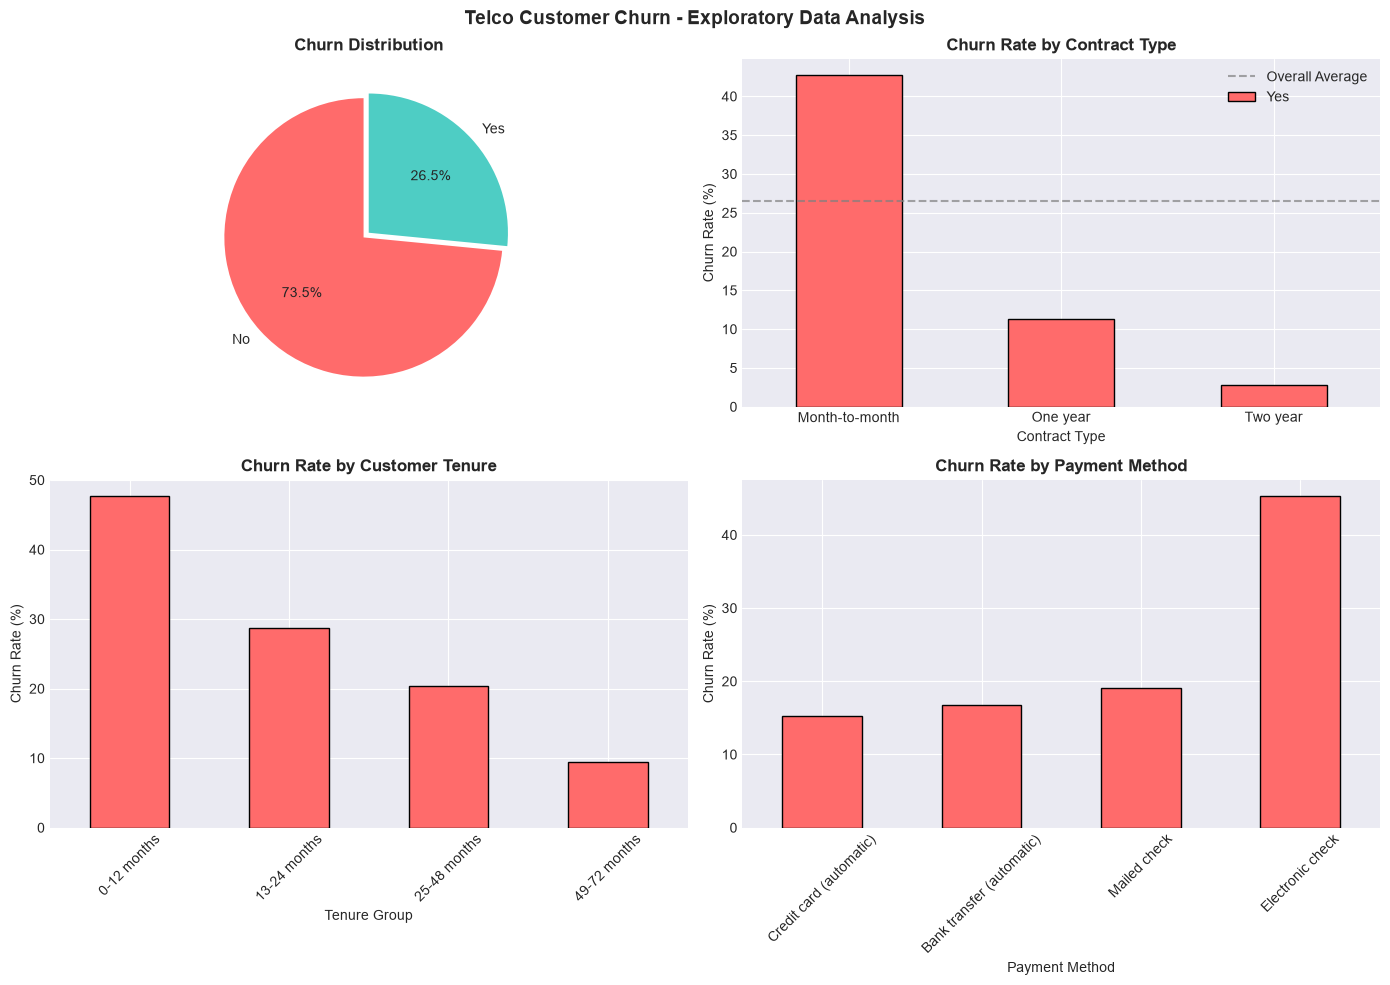

In [8]:
# 2 EXPLORATORY DATA ANALYSIS 

print("\n  Exploratory Data Analysis...")

# basic statistics
print("\nBasic Dataset Info:")
print(f"  - Missing values: {df.isnull().sum().sum()}")  
print(f"  - Duplicate rows: {df.duplicated().sum()}")    
print(f"  - Churn rate: {(df['Churn'] == 'Yes').mean() * 100:.2f}%")  

# create visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Telco Customer Churn - Exploratory Data Analysis',
             fontsize=14, fontweight='bold')

# 1churn Distribution (Pie chart)
churn_counts = df['Churn'].value_counts()
axes[0, 0].pie(churn_counts.values, labels=churn_counts.index,
               autopct='%1.1f%%',
               colors=['#ff6b6b', '#4ecdc4'], explode=[0.05, 0],
               startangle=90)
axes[0, 0].set_title('Churn Distribution', fontweight='bold')

# 2churn by Contract Type (Bar chart)
contract_churn = pd.crosstab(df['Contract'], df['Churn'],
                             normalize='index') * 100
contract_churn['Yes'].plot(kind='bar', ax=axes[0, 1], color='#ff6b6b',
                           edgecolor='black')
axes[0, 1].set_title('Churn Rate by Contract Type', fontweight='bold')
axes[0, 1].set_ylabel('Churn Rate (%)')
axes[0, 1].set_xlabel('Contract Type')
axes[0, 1].axhline(y=(df['Churn'] == 'Yes').mean() * 100, color='gray',
                   linestyle='--', label='Overall Average', alpha=0.7)
axes[0, 1].legend()
axes[0, 1].tick_params(axis='x', rotation=0)

# 3Churn by Tenure (Bar chart)
df['tenure_group'] = pd.cut(df['tenure'], bins=[0, 12, 24, 48, 72],
                            labels=['0-12 months', '13-24 months',
                                    '25-48 months', '49-72 months'])
tenure_churn = pd.crosstab(df['tenure_group'], df['Churn'],
                           normalize='index') * 100
tenure_churn['Yes'].plot(kind='bar', ax=axes[1, 0], color='#ff6b6b',
                         edgecolor='black')
axes[1, 0].set_title('Churn Rate by Customer Tenure', fontweight='bold')
axes[1, 0].set_ylabel('Churn Rate (%)')
axes[1, 0].set_xlabel('Tenure Group')
axes[1, 0].tick_params(axis='x', rotation=45)

# 4churn by Payment Method (Bar chart)
payment_churn = pd.crosstab(df['PaymentMethod'], df['Churn'],
                            normalize='index') * 100
payment_churn['Yes'].sort_values().plot(kind='bar', ax=axes[1, 1],
                                        color='#ff6b6b', edgecolor='black')
axes[1, 1].set_title('Churn Rate by Payment Method', fontweight='bold')
axes[1, 1].set_ylabel('Churn Rate (%)')
axes[1, 1].set_xlabel('Payment Method')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


In [16]:
#3 Data Preprocessing
print("\n Step 3: Data Preprocessing...")


df_model = df.copy()

# drop customerID (not useful for prediction)
if 'customerID' in df_model.columns:
    df_model = df_model.drop('customerID', axis=1)

# remove temporary tenure_group column if it exists
if 'tenure_group' in df_model.columns:
    df_model = df_model.drop('tenure_group', axis=1)

# Convert TotalCharges to numeric (it might be string with empty spaces)
if 'TotalCharges' in df_model.columns:
    df_model['TotalCharges'] = pd.to_numeric(df_model['TotalCharges'], errors='coerce')

# Fill missing TotalCharges with MonthlyCharges (reasonable assumption)
df_model['TotalCharges'] = df_model['TotalCharges'].fillna(df_model['MonthlyCharges'])


# Separate features and target
X = df_model.drop('Churn', axis=1)
y = df_model['Churn'].map({'Yes': 1, 'No': 0})

# Identify column types
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"\n  - Numerical features ({len(numerical_cols)}): {numerical_cols}")
print(f"  - Categorical features ({len(categorical_cols)}): {categorical_cols}")

# Encode categorical variables
print("\n  Encoding categorical variables...")
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le
    print(f"    ✓ {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Scale numerical features
print("\n  Scaling numerical features...")
scaler = StandardScaler()
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

# Verify all data is numeric
print("\n  Data validation:")
print(f"    - All features numeric: {all(pd.api.types.is_numeric_dtype(X[col]) for col in X.columns)}")
print(f"    - Missing values: {X.isnull().sum().sum()}")
print(f"    - Data types: {X.dtypes.unique()}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n  Training set: {X_train.shape[0]} samples")
print(f"  Test set: {X_test.shape[0]} samples")
print(f"  Class distribution (training):")
print(f"    - No Churn: {(y_train == 0).sum()} ({(y_train == 0).mean()*100:.1f}%)")
print(f"    - Churn: {(y_train == 1).sum()} ({(y_train == 1).mean()*100:.1f}%)")




 Step 3: Data Preprocessing...

  - Numerical features (4): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
  - Categorical features (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

  Encoding categorical variables...
    ✓ gender: {'Female': np.int64(0), 'Male': np.int64(1)}
    ✓ Partner: {'No': np.int64(0), 'Yes': np.int64(1)}
    ✓ Dependents: {'No': np.int64(0), 'Yes': np.int64(1)}
    ✓ PhoneService: {'No': np.int64(0), 'Yes': np.int64(1)}
    ✓ MultipleLines: {'No': np.int64(0), 'No phone service': np.int64(1), 'Yes': np.int64(2)}
    ✓ InternetService: {'DSL': np.int64(0), 'Fiber optic': np.int64(1), 'No': np.int64(2)}
    ✓ OnlineSecurity: {'No': np.int64(0), 'No internet service': np.int64(1), 'Yes': np.int64(2)}
    ✓ OnlineBackup: {'No': np.int64(0), 'No internet s

In [17]:
# 4data training 
print("\n training models....")
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=10, min_samples_split=20),
    'RandomForestClassifier':RandomForestClassifier(random_state=42, n_estimators=100, max_depth=10, min_samples_split=20, n_jobs=-1),
    'XGBoost': xgb.XGBClassifier(random_state=42, n_estimators=100, max_depth=6, learning_rate=0.1, eval_metric='logloss'), 
    'Gradient Boosting': GradientBoostingClassifier(random_state=42, n_estimators=100,  max_depth=5, learning_rate=0.1) 
}

results = {}
trained_models ={}

for name, model in models.items():
    print(f"\n training {name}....")
    try:
        #train
        model.fit(X_train, y_train)
        trained_models[name] = model

        # predict
        y_pred = model.predict(X_test)
        y_pred_proba= model.predict_proba(X_test) [:, 1]

        #metrics
        results[name] = {
            'Accuracy': accuracy_score(y_test, y_pred), 
            'Precision': precision_score(y_test, y_pred), 
            'Recall': recall_score(y_test, y_pred), 
            'F1-Score': f1_score(y_test, y_pred), 
            'ROC-AUC': roc_auc_score(y_test, y_pred_proba) 
        }

        print(f"    ✓ Accuracy: {results[name]['Accuracy']:.4f}") 
        print(f"    ✓ ROC-AUC: {results[name]['ROC-AUC']:.4f}") 
         
    except Exception as e: 
        print(f"    ✗ Error: {str(e)}") 
        results[name] = {'Accuracy': 0, 'Precision': 0, 'Recall': 0, 'F1- Score': 0, 'ROC-AUC': 0} 






 training models....

 training Decision Tree....
    ✓ Accuracy: 0.7807
    ✓ ROC-AUC: 0.7892

 training RandomForestClassifier....
    ✓ Accuracy: 0.8006
    ✓ ROC-AUC: 0.8413

 training XGBoost....
    ✓ Accuracy: 0.7949
    ✓ ROC-AUC: 0.8357

 training Gradient Boosting....
    ✓ Accuracy: 0.7956
    ✓ ROC-AUC: 0.8361



Generating Visualizations...


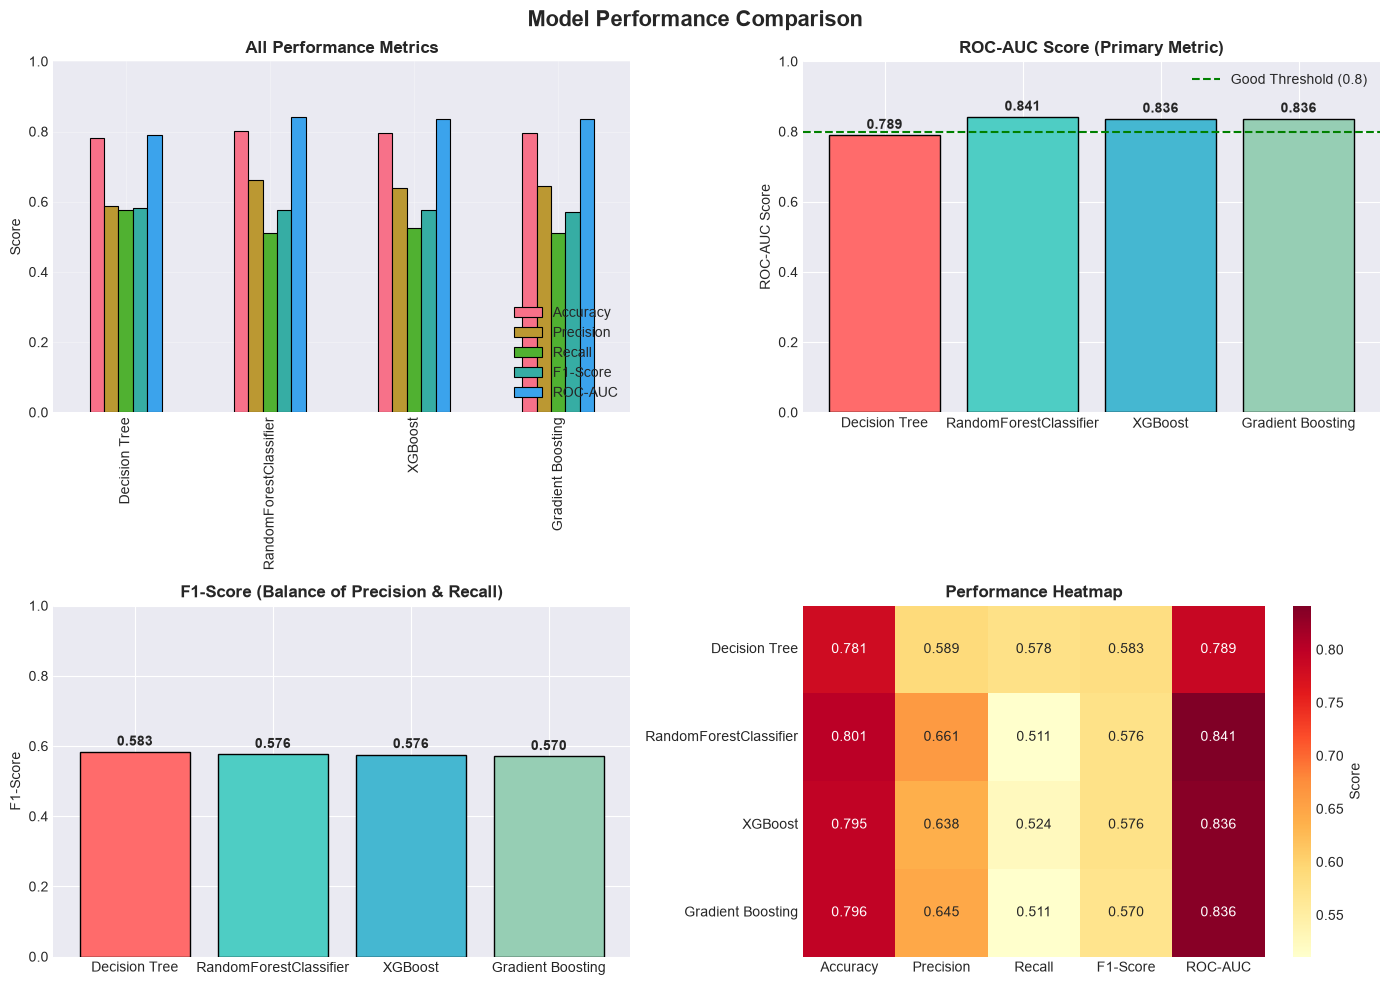

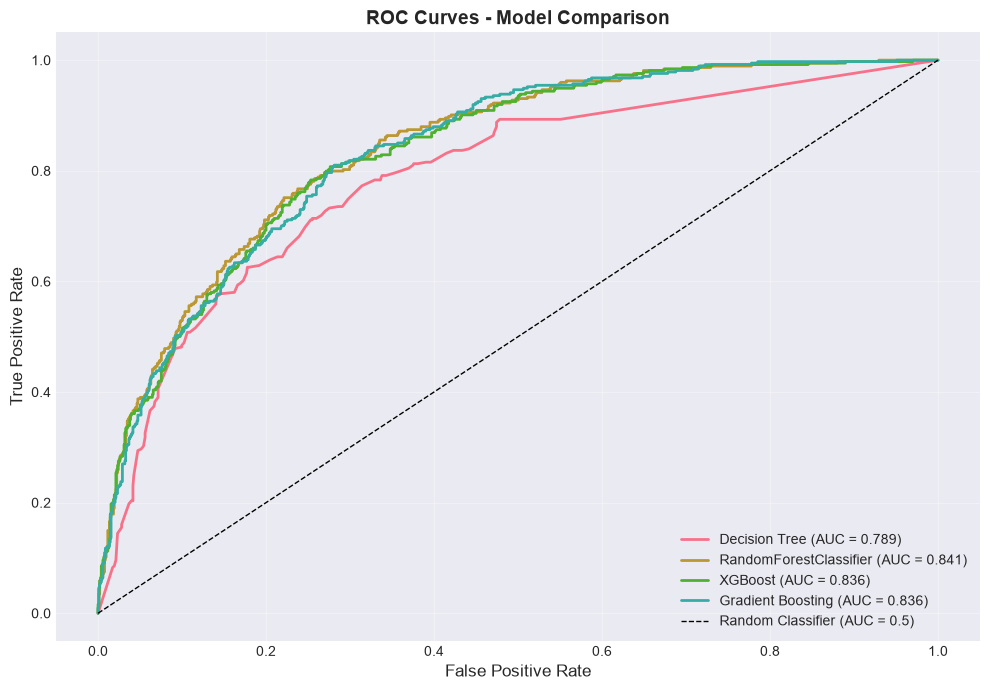

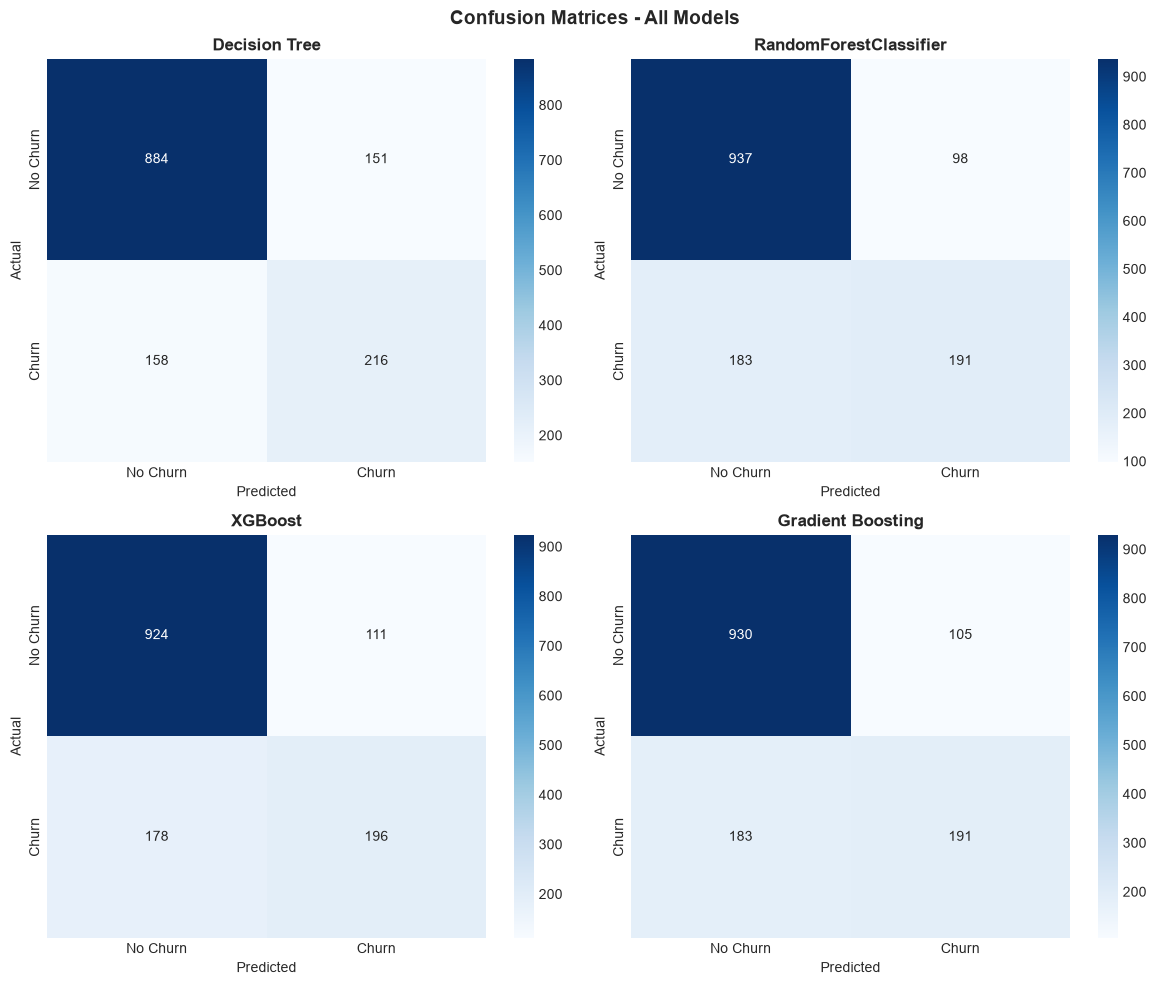


 Generating Learning Curves...


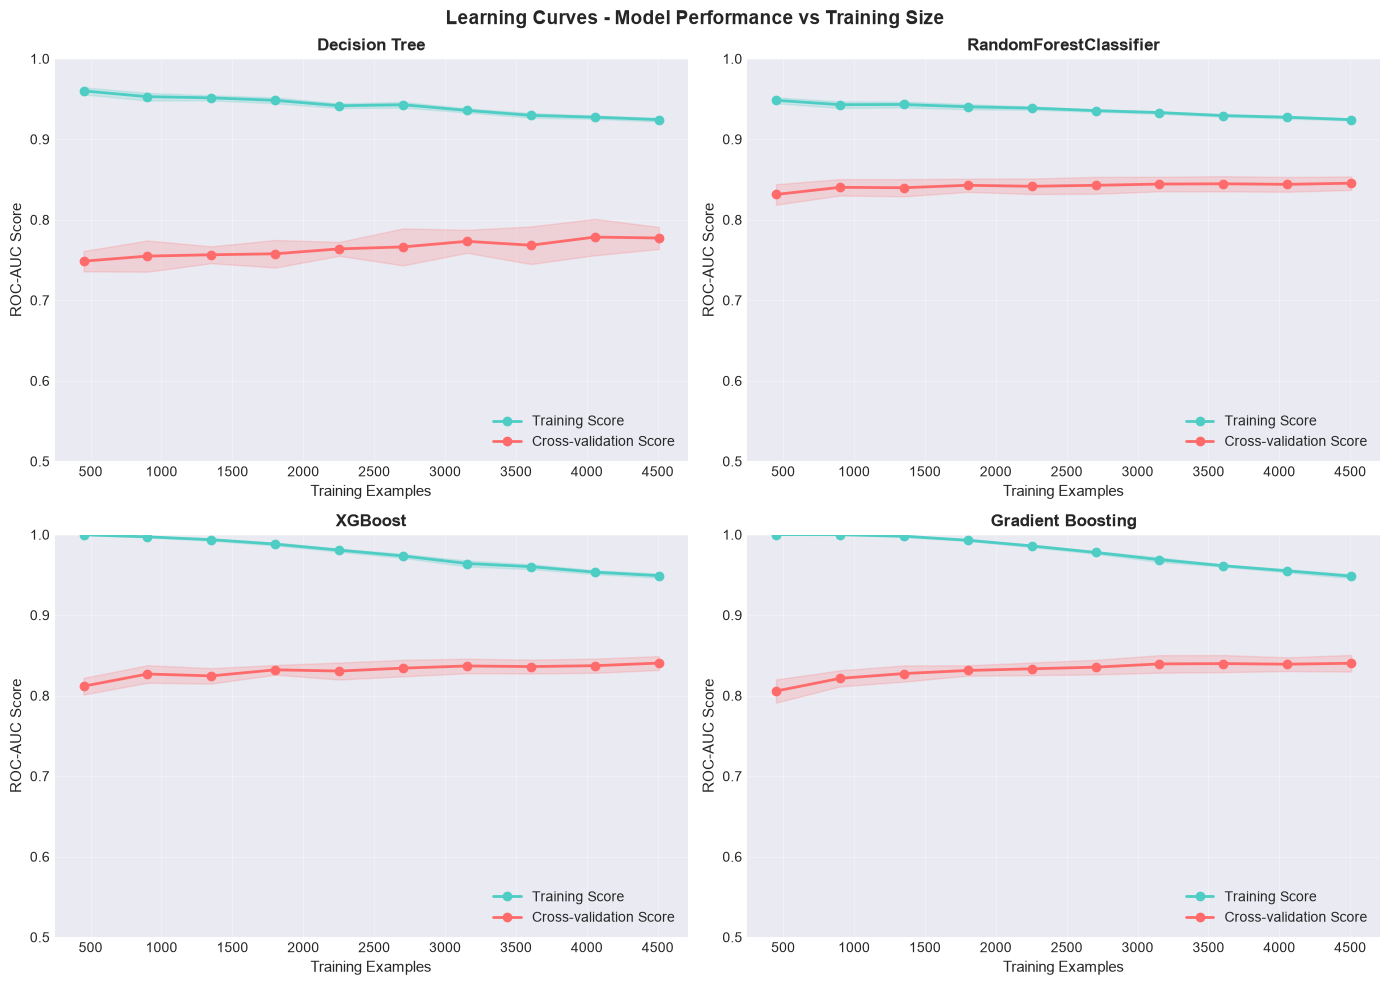


 Feature Importance Analysis - RandomForestClassifier


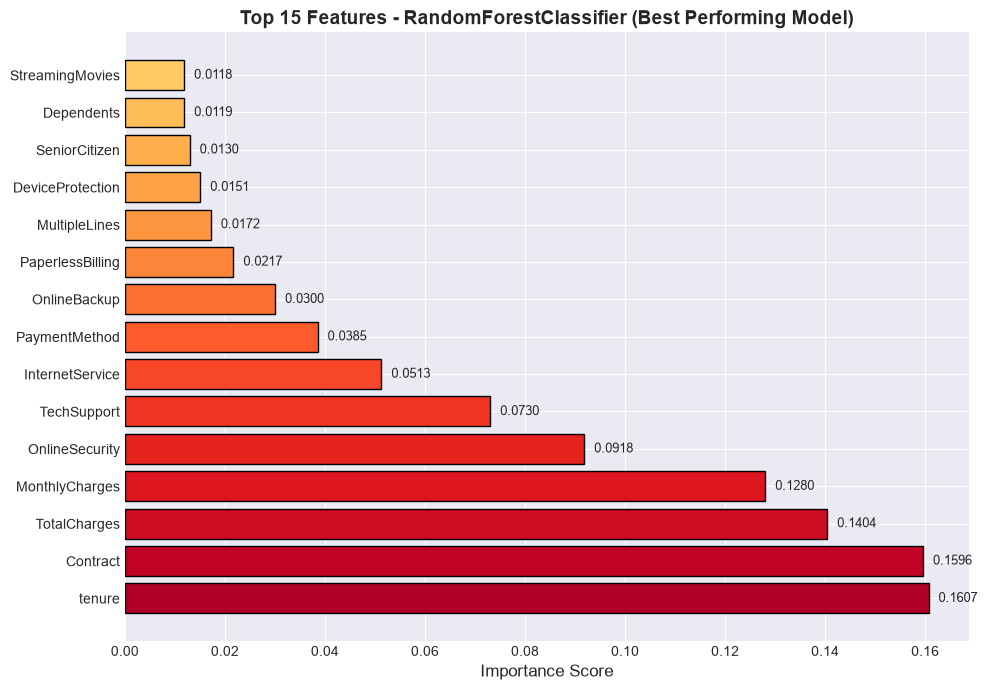

In [20]:
#RESULTS & VISUALIZATIONS

print("\nGenerating Visualizations...")

# Create results dataframe
results_df = pd.DataFrame(results).T

# Figure 1: Performance Comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')

# Bar plot - all metrics
results_df.plot(kind='bar', ax=axes[0, 0], edgecolor='black', linewidth=0.8)
axes[0, 0].set_title('All Performance Metrics', fontweight='bold')
axes[0, 0].set_ylabel('Score')
axes[0, 0].set_ylim([0, 1])
axes[0, 0].legend(loc='lower right')
axes[0, 0].grid(True, alpha=0.3)

# ROC-AUC comparison
colors = ['#ff6b6b', '#4ecdc4', '#45b7d1', '#96ceb4']
bars = axes[0, 1].bar(results_df.index, results_df['ROC-AUC'],
                      color=colors[:len(results_df)], edgecolor='black')
axes[0, 1].set_title('ROC-AUC Score (Primary Metric)', fontweight='bold')
axes[0, 1].set_ylabel('ROC-AUC Score')
axes[0, 1].set_ylim([0, 1])
axes[0, 1].axhline(y=0.8, color='green', linestyle='--', label='Good Threshold (0.8)')
axes[0, 1].legend()
for bar, score in zip(bars, results_df['ROC-AUC']):
    if score > 0:
        axes[0, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                        f'{score:.3f}', ha='center', va='bottom', fontweight='bold')

# F1-Score comparison
bars = axes[1, 0].bar(results_df.index, results_df['F1-Score'],
                      color=colors[:len(results_df)], edgecolor='black')
axes[1, 0].set_title('F1-Score (Balance of Precision & Recall)', fontweight='bold')
axes[1, 0].set_ylabel('F1-Score')
axes[1, 0].set_ylim([0, 1])
for bar, score in zip(bars, results_df['F1-Score']):
    if score > 0:
        axes[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                        f'{score:.3f}', ha='center', va='bottom', fontweight='bold')

# Heatmap
sns.heatmap(results_df, annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[1, 1],
            cbar_kws={'label': 'Score'})
axes[1, 1].set_title('Performance Heatmap', fontweight='bold')

plt.tight_layout()
plt.show()

# Figure 2: ROC Curves
plt.figure(figsize=(10, 7))
for name, model in trained_models.items():
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    auc = results[name]['ROC-AUC']
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.5)')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - Model Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Figure 3: Confusion Matrices
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Confusion Matrices - All Models', fontsize=14, fontweight='bold')
for idx, (name, model) in enumerate(trained_models.items()):
    if idx < 4:
        y_pred = model.predict(X_test)
        cm = confusion_matrix(y_test, y_pred)
        row, col = divmod(idx, 2)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[row, col],
                    xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
        axes[row, col].set_title(name, fontweight='bold')
        axes[row, col].set_xlabel('Predicted')
        axes[row, col].set_ylabel('Actual')
plt.tight_layout()
plt.show()

# Figure 4: Learning Curves
print("\n Generating Learning Curves...")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Learning Curves - Model Performance vs Training Size', fontsize=14, fontweight='bold')
for idx, (name, model) in enumerate(trained_models.items()):
    if idx < 4:
        row, col = divmod(idx, 2)
        try:
            train_sizes, train_scores, test_scores = learning_curve(
                model, X_train, y_train,
                cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                train_sizes=np.linspace(0.1, 1.0, 10),
                scoring='roc_auc',
                n_jobs=-1
            )
            train_mean = np.mean(train_scores, axis=1)
            train_std = np.std(train_scores, axis=1)
            test_mean = np.mean(test_scores, axis=1)
            test_std = np.std(test_scores, axis=1)

            axes[row, col].plot(train_sizes, train_mean, 'o-', color='#4ecdc4', linewidth=2, label='Training Score')
            axes[row, col].fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color='#4ecdc4')
            axes[row, col].plot(train_sizes, test_mean, 'o-', color='#ff6b6b', linewidth=2, label='Cross-validation Score')
            axes[row, col].fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.2, color='#ff6b6b')
            axes[row, col].set_xlabel('Training Examples', fontsize=11)
            axes[row, col].set_ylabel('ROC-AUC Score', fontsize=11)
            axes[row, col].set_title(name, fontweight='bold')
            axes[row, col].legend(loc='lower right')
            axes[row, col].grid(True, alpha=0.3)
            axes[row, col].set_ylim([0.5, 1.0])
        except Exception as e:
            axes[row, col].text(0.5, 0.5, f'Could not generate\nlearning curve\n{str(e)[:50]}',
                                ha='center', va='center', transform=axes[row, col].transAxes)
            axes[row, col].set_title(name)
plt.tight_layout()
plt.show()

# Figure 5: Feature Importance (for best model)
best_model_name = max(results, key=lambda x: results[x]['ROC-AUC'] if results[x]['ROC-AUC'] > 0 else -1)
best_model = trained_models.get(best_model_name)
if best_model and hasattr(best_model, 'feature_importances_'):
    print(f"\n Feature Importance Analysis - {best_model_name}")
    importances = best_model.feature_importances_
    indices = np.argsort(importances)[-15:]
    plt.figure(figsize=(10, 7))
    colors_bar = plt.cm.YlOrRd(np.linspace(0.3, 0.9, 15))
    bars = plt.barh(range(15), importances[indices], color=colors_bar, edgecolor='black')
    plt.yticks(range(15), [X.columns[i] for i in indices])
    plt.xlabel('Importance Score', fontsize=12)
    plt.title(f'Top 15 Features - {best_model_name} (Best Performing Model)', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    for i, (bar, val) in enumerate(zip(bars, importances[indices])):
        plt.text(val + 0.002, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontsize=9)
    plt.tight_layout()
    plt.show()


In [23]:

#FINAL SUMMARY
print("FINAL RESULTS SUMMARY")

# Results table
print(f"\n{'Model':<20} {'ROC-AUC':<12} {'F1-Score':<12} {'Accuracy':<12} {'Precision':<12} {'Recall':<12}")
for name, metrics in results.items():
    print(f"{name:<20} {metrics['ROC-AUC']:<12.4f} {metrics['F1-Score']:<12.4f} "
          f"{metrics['Accuracy']:<12.4f} {metrics['Precision']:<12.4f} {metrics['Recall']:<12.4f}")


print("RECOMMENDATIONS & INSIGHTS")


# Find best model
best_model = max(results, key=lambda x: results[x]['ROC-AUC'])
best_score = results[best_model]['ROC-AUC']

print(f"\n Best Performing Model: {best_model}")
print(f"   • ROC-AUC Score: {best_score:.4f}")
print(f"   • F1-Score: {results[best_model]['F1-Score']:.4f}")
print(f"   • Accuracy: {results[best_model]['Accuracy']:.4f}")

# Business insights
print("\n Key Business Insights from Data:")
print("   • Customers with month-to-month contracts have the highest churn risk")
print("   • Churn is highest during first 12 months of customer tenure")
print("   • Electronic check payment method correlates with higher churn")
print("   • Customers without additional services (tech support, online security) churn more")
print("   • Senior citizens show different churn patterns than younger customers")

# Recommendations
print("\n Actionable Recommendations:")
print("   • Offer incentives for longer-term contracts")
print("   • Implement early retention programs for new customers (first year)")
print("   • Promote paperless billing & automatic payment methods")
print("   • Bundle services to increase customer stickiness")
print("   • Create targeted offers for high-risk segments")

print("\n Analysis Complete! Check all generated visualizations above.")


FINAL RESULTS SUMMARY

Model                ROC-AUC      F1-Score     Accuracy     Precision    Recall      
Decision Tree        0.7892       0.5830       0.7807       0.5886       0.5775      
RandomForestClassifier 0.8413       0.5762       0.8006       0.6609       0.5107      
XGBoost              0.8357       0.5756       0.7949       0.6384       0.5241      
Gradient Boosting    0.8361       0.5701       0.7956       0.6453       0.5107      
RECOMMENDATIONS & INSIGHTS

 Best Performing Model: RandomForestClassifier
   • ROC-AUC Score: 0.8413
   • F1-Score: 0.5762
   • Accuracy: 0.8006

 Key Business Insights from Data:
   • Customers with month-to-month contracts have the highest churn risk
   • Churn is highest during first 12 months of customer tenure
   • Electronic check payment method correlates with higher churn
   • Customers without additional services (tech support, online security) churn more
   • Senior citizens show different churn patterns than younger customers

